# Global Climate Indicators Dashboard

## CO₂ Emissions and Temperature Anomalies Analysis

This project explores the relationship between atmospheric CO₂ emissions and global temperature anomalies using datasets from NASA GISS and Our World in Data.

## Objective

The goal of this project is to analyze long-term trends in climate indicators and determine whether there is a measurable relationship between CO₂ emissions and global temperature change.

We specifically investigate:
- How temperature anomalies have changed over time
- How CO₂ emissions have changed over time
- Whether a correlation exists between the two variables

## Data Sources

This project uses two main datasets:

- NASA GISS Surface Temperature Analysis (GISTEMP): global temperature anomaly data
- Our World in Data: global CO₂ emissions dataset

Both datasets provide long-term historical climate measurements suitable for trend analysis.

## Data Preparation

The datasets were cleaned and processed to ensure consistency:

- Removed missing values
- Standardized column names
- Converted data types to numeric format
- Aligned both datasets by year for comparison

After cleaning, the datasets were merged into a single DataFrame for analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Temperature Analysis

The temperature dataset shows global temperature anomalies over time.

Key observation:
- A clear upward trend is visible, especially after the mid-20th century
- This indicates a long-term increase in global temperatures

In [2]:
df = pd.read_csv("NH.Ts+dSST.csv", skiprows=1)

# preview
df.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.37,-0.53,-0.25,-.32,-.08,-.18,-.21,-.29,-.25,-.33,-.45,-.43,-.31,***,***,-.21,-.22,-.34
1,1881,-0.31,-0.26,-0.06,-.03,.03,-.34,.09,-.06,-.28,-.44,-.37,-.24,-.19,-.21,-.33,-.02,-.10,-.36
2,1882,0.25,0.21,0.01,-.31,-.24,-.29,-.28,-.17,-.26,-.52,-.34,-.69,-.22,-.18,.07,-.18,-.25,-.38
3,1883,-0.58,-0.65,-0.16,-.29,-.25,-.12,-.07,-.23,-.34,-.16,-.45,-.16,-.29,-.33,-.64,-.23,-.14,-.32
4,1884,-0.17,-0.11,-0.64,-.60,-.36,-.42,-.41,-.51,-.45,-.45,-.58,-.48,-.43,-.41,-.15,-.53,-.45,-.50


In [3]:
df.columns = df.columns.str.strip()

df_clean = df[['Year', 'J-D']].copy()
df_clean.columns = ['Year', 'Temp_Anomaly']

df_clean = df_clean[df_clean['Temp_Anomaly'] != '***']

df_clean['Temp_Anomaly'] = df_clean['Temp_Anomaly'].astype(float)
df_clean['Year'] = df_clean['Year'].astype(int)

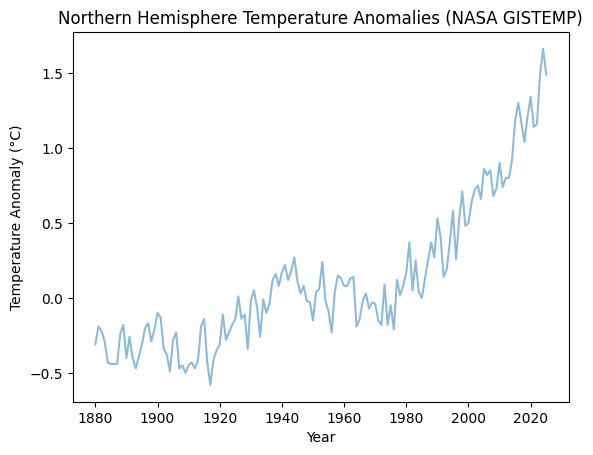

In [4]:
plt.plot(df_clean['Year'], df_clean['Temp_Anomaly'], alpha=0.5)
plt.title("Northern Hemisphere Temperature Anomalies (NASA GISTEMP)")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.show()

In [ ]:
plt.hist(df_clean['Temp_Anomaly'], bins=20)
plt.title("Distribution of Temperature Anomalies")
plt.xlabel("Temperature Anomaly")
plt.ylabel("Frequency")
plt.show()

## CO₂ Emissions Analysis

The CO₂ dataset shows a steady increase in atmospheric carbon emissions over time.

Key observation:
- CO₂ levels rise significantly after industrial expansion
- This trend aligns with increased human industrial activity and fossil fuel use

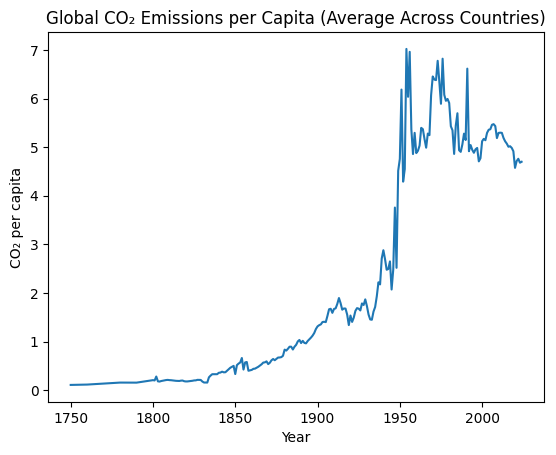

In [5]:
# Load dataset
co2 = pd.read_csv("co2-emissions-per-capita.csv")

# Keep only needed columns and drop missing values
co2 = co2[['Entity', 'Year', 'CO₂ emissions per capita']].dropna()

# Convert types
co2['Year'] = co2['Year'].astype(int)
co2['CO2'] = co2['CO₂ emissions per capita'].astype(float)

# Remove country codes that are not actual countries (optional but cleaner)
co2 = co2[~co2['Entity'].isin(['World'])]

# Aggregate: global average CO₂ per year (since no "World" row exists)
co2_yearly = co2.groupby('Year')['CO2'].mean().reset_index()

# Plot
plt.plot(co2_yearly['Year'], co2_yearly['CO2'])
plt.title("Global CO₂ Emissions per Capita (Average Across Countries)")
plt.xlabel("Year")
plt.ylabel("CO₂ per capita")
plt.show()

In [ ]:
plt.hist(co2_yearly['CO2'], bins=20)
plt.title("Distribution of CO₂ Emissions")
plt.xlabel("CO₂")
plt.ylabel("Frequency")
plt.show()

## Relationship Between CO₂ and Temperature

A correlation analysis was performed to examine the relationship between CO₂ emissions and temperature anomalies.

Findings:
- A moderate positive correlation was observed (~0.56)
- This suggests that increases in CO₂ are associated with rising global temperatures

In [6]:
merged = pd.merge(df_clean, co2_yearly, on='Year')

merged.head()

,Year,Temp_Anomaly,CO2
0,1880,-0.31,0.834880
1,1881,-0.19,0.814826
2,1882,-0.22,0.851511
3,1883,-0.29,0.895059
4,1884,-0.43,0.894307


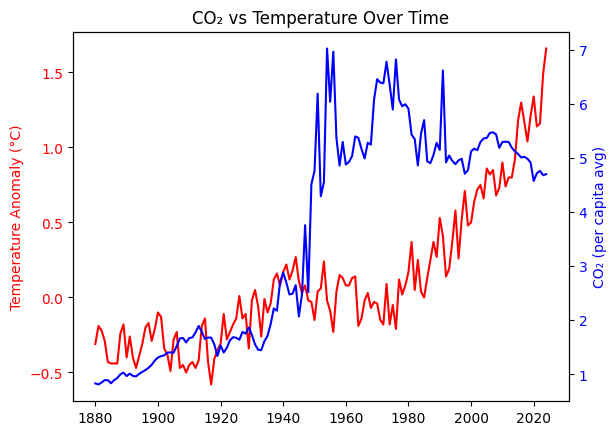

In [7]:
fig, ax1 = plt.subplots()

# Temperature
ax1.plot(merged['Year'], merged['Temp_Anomaly'], color='red', label='Temperature')
ax1.set_ylabel('Temperature Anomaly (°C)', color='red')
ax1.tick_params(axis='y', labelcolor='red')

# CO2 on second axis
ax2 = ax1.twinx()
ax2.plot(merged['Year'], merged['CO2'], color='blue', label='CO2')
ax2.set_ylabel('CO₂ (per capita avg)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("CO₂ vs Temperature Over Time")
plt.show()

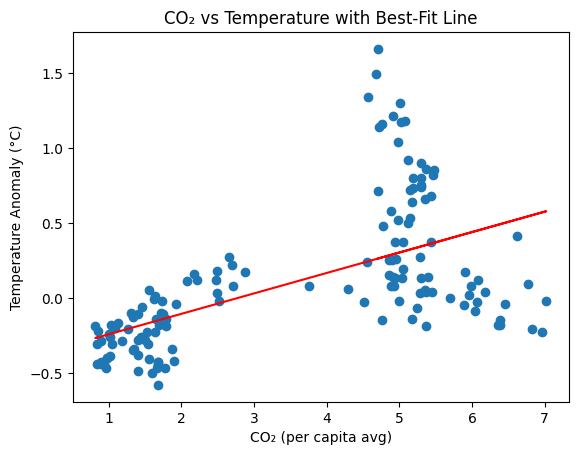

In [8]:
# Scatter plot
plt.scatter(merged['CO2'], merged['Temp_Anomaly'])

# Fit a line (linear regression)
m, b = np.polyfit(merged['CO2'], merged['Temp_Anomaly'], 1)

# Create line values
x = merged['CO2']
y = m * x + b

# Plot best-fit line
plt.plot(x, y, color='red')

# Labels
plt.title("CO₂ vs Temperature with Best-Fit Line")
plt.xlabel("CO₂ (per capita avg)")
plt.ylabel("Temperature Anomaly (°C)")

plt.show()

In [9]:
merged[['Temp_Anomaly', 'CO2']].corr()

,Temp_Anomaly,CO2
Temp_Anomaly,1.000000,0.566221
CO2,0.566221,1.000000


In [ ]:
merged['Temp_Rolling'] = merged['Temp_Anomaly'].rolling(10).mean()

plt.plot(merged['Year'], merged['Temp_Anomaly'], alpha=0.3)
plt.plot(merged['Year'], merged['Temp_Rolling'])
plt.title("Temperature Trend with Rolling Average")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly")
plt.show()

In [ ]:
fig, ax1 = plt.subplots()

ax1.plot(merged['Year'], merged['Temp_Anomaly'])
ax1.set_ylabel("Temperature")

ax2 = ax1.twinx()
ax2.plot(merged['Year'], merged['CO2'])
ax2.set_ylabel("CO₂")

plt.title("CO₂ vs Temperature Over Time")
plt.show()

## Conclusion

The analysis shows that CO₂ emissions and global temperature anomalies are positively related over time. While the relationship is not perfectly linear, the consistent upward trends in both datasets support the conclusion that greenhouse gas emissions are associated with global warming.

This reinforces the importance of monitoring emissions as a key factor in climate change.

 ## Limitations

- CO₂ data is averaged across countries and may not represent exact global totals
- Temperature data focuses on anomalies rather than absolute temperatures
- Correlation does not imply causation, only association